# Metrics Analysis -- so sánh 5 thí nghiệm PhoBERT

Đọc toàn bộ `results/metrics/metrics_<experiment>.json` (do 3 notebook trong `4_model_training/` tạo ra), gộp thành 1 bảng so sánh, vẽ biểu đồ, lưu vào `results/metrics/` và `results/figures/`.

Logic đọc file/gộp bảng nằm ở `src/utils/evaluation.py` (dùng chung với `scripts/summarize_ablation.py` -- bản CLI tự động của chính notebook này). Notebook này chỉ lo phần trực quan hoá.

## Setup

In [13]:
%pip install torch transformers pandas numpy scikit-learn matplotlib py_vncorenlp seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve().parents[1]

sys.path.insert(0, str(PROJECT_DIR)) 

DATA_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
ERROR_ANALYSIS_DIR = RESULTS_DIR / "error_analysis"
for d in [FIGURES_DIR, ERROR_ANALYSIS_DIR]:    

    d.mkdir(parents=True, exist_ok=True)
    assert (PROJECT_DIR / "src").exists(), "PROJECT_DIR looks wrong -- adjust .parents[N] above."
print(f"Project root: {PROJECT_DIR}")

Project root: D:\prj_it\Hate_Speech_Detection


In [4]:
from src.utils.evaluation import load_all_metrics

d:\prj_it\Hate_Speech_Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load bảng metrics từ toàn bộ thí nghiệm đã train

In [6]:
summary_df = load_all_metrics(RESULTS_DIR)
summary_df = summary_df.set_index("experiment").reindex([e for e in ["baseline", "bt", "eda", "llm", "combined"] if e in summary_df.set_index("experiment").index]).reset_index()
summary_df

,experiment,loss,accuracy,macro_f1,weighted_f1,hate_f1
0,baseline,0.435646,0.844130,0.602212,0.847464,0.537500
1,bt,0.510528,0.832573,0.606315,0.843621,0.571895
2,eda,0.566266,0.784367,0.582761,0.813251,0.560000
3,llm,0.498562,0.834702,0.609269,0.844948,0.560996
4,combined,0.548771,0.800791,0.594815,0.823251,0.590206


In [7]:
summary_path = RESULTS_DIR / "experiments_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")

Saved: D:\prj_it\Hate_Speech_Detection\results\experiments_summary.csv


## Biểu đồ so sánh 4 chỉ số chính

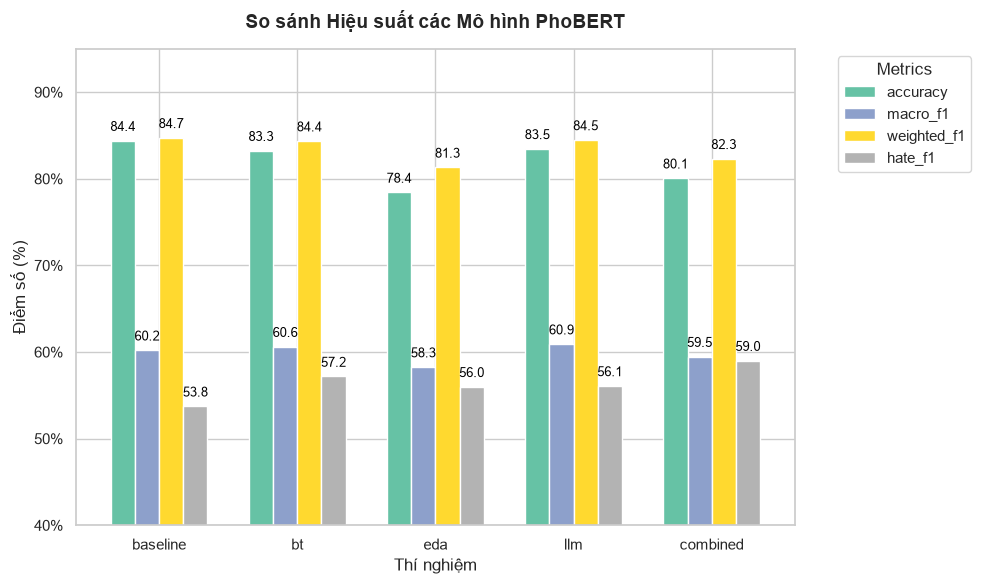

In [14]:
import seaborn as sns
import matplotlib.ticker as mtick

# Bật theme hiện đại của Seaborn
sns.set_theme(style="whitegrid")

metric_cols = [c for c in ["accuracy", "macro_f1", "weighted_f1", "hate_f1"] if c in summary_df.columns]

# Nhân 100 để đổi sang thang %
df_pct = summary_df.set_index("experiment")[metric_cols] * 100

fig, ax = plt.subplots(figsize=(10, 6))
# Dùng colormap Set2 cho màu sắc pastel dịu mắt
df_pct.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.7)

# Căn chỉnh tiêu đề và trục
ax.set_title("So sánh Hiệu suất các Mô hình PhoBERT", fontsize=14, pad=15, fontweight='bold')
ax.set_ylabel("Điểm số (%)", fontsize=12)
ax.set_xlabel("Thí nghiệm", fontsize=12)
ax.set_ylim(40, 95) # Zoom vào khoảng 40-95% để thấy rõ sự khác biệt
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=0, fontsize=11)

# Gắn nhãn giá trị (Data labels) lên đỉnh từng cột
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=9, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Đưa Legend ra ngoài biểu đồ
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

fig_path = FIGURES_DIR / "metrics_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

## Riêng `hate_f1` -- chỉ số quan trọng nhất cho bài toán HSD

`macro_f1`/`accuracy` có thể bị chi phối bởi lớp CLEAN (chiếm đa số). `hate_f1` cho biết model có thực sự nhận diện tốt câu HATE hay không -- đây thường là chỉ số nên dẫn đầu trong phần kết luận báo cáo.

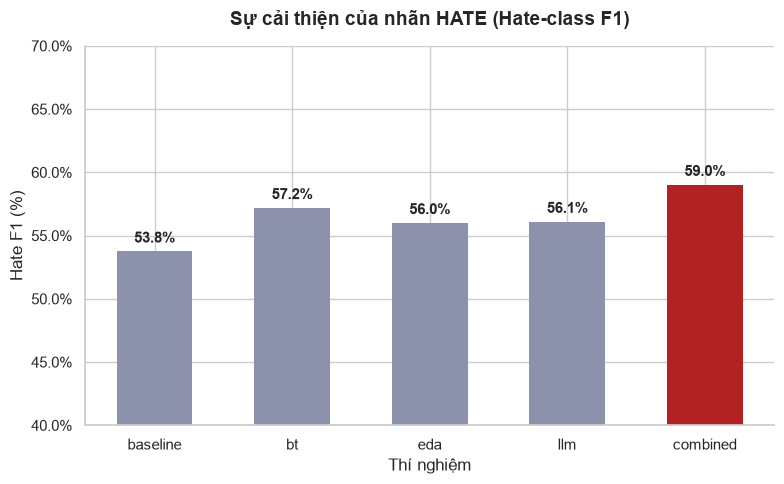

In [15]:
if "hate_f1" in summary_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    hate_f1_pct = summary_df.set_index("experiment")["hate_f1"] * 100
    
    # Highlight: Tô màu đỏ đô cho 'combined', các mô hình khác màu xám xanh
    colors = ['#8C92AC' if exp != 'combined' else '#B22222' for exp in hate_f1_pct.index]
    
    bars = ax.bar(hate_f1_pct.index, hate_f1_pct.values, color=colors, width=0.55, edgecolor="none")
    
    ax.set_title("Sự cải thiện của nhãn HATE (Hate-class F1)", fontsize=14, pad=15, fontweight='bold')
    ax.set_ylabel("Hate F1 (%)", fontsize=12)
    ax.set_xlabel("Thí nghiệm", fontsize=12)
    ax.set_ylim(40, 70) # Zoom vào khu vực 40-70%
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    # Gắn nhãn giá trị in đậm
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    sns.despine() # Xóa đường viền trên và phải cho thoáng
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "hate_f1_comparison.png", dpi=300)
    plt.show()